### installation liblarry


In [12]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [13]:
!pip install google-api-python-client pandas tqdm
!pip install nltk
!pip install Sastrawi
!pip install wordcloud
!pip install matplotlib
!pip install scikit-learn
!pip install gensim
!pip install networkx

In [14]:
!pip install pyLDAvis

In [15]:
!pip install youtube-comment-downloader


In [16]:
!pip install Sastrawi emoji nltk

In [17]:
from IPython.display import clear_output

clear_output(wait=True)

print("✅ Semua library berhasil diinstall.")

✅ Semua library berhasil diinstall.


### Import Liblary

In [18]:
# =====================
# BASIC LIBRARY
# =====================
import re
import string
import warnings
warnings.filterwarnings("ignore")
from youtube_comment_downloader import YoutubeCommentDownloader


import numpy as np
import pandas as pd

# =====================
# VISUALIZATION
# =====================
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# =====================
# NLP CORE
# =====================
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# download resource NLTK
nltk.download("punkt")
nltk.download("stopwords")

# Sastrawi (Indonesian Stemmer)
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
stemmer = StemmerFactory().create_stemmer()

# =====================
# TOPIC MODELING (LDA)
# =====================
import gensim
from gensim import corpora
from gensim.models import LdaModel

import pyLDAvis
import pyLDAvis.gensim_models

# =====================
# NER (Named Entity Recognition)
# =====================

# load NER model (English pretrained)


# =====================
# FEATURE EXTRACTION + CLUSTERING (FTC / KMEANS)
# =====================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# =====================
# SOCIAL NETWORK ANALYSIS
# =====================
import networkx as nx

# =====================
# PROGRESS BAR (optional but useful for scraping)
# =====================
from tqdm import tqdm

# =====================
# TIME CONTROL (for scraping stability)
# =====================
import time

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


###Crawling Data

In [19]:
import re
import pandas as pd

def normalize_time(time_text):

    if pd.isna(time_text):
        return ""

    time_text = str(time_text).strip().lower()

    patterns = [

        # ======================
        # INDONESIA
        # ======================
        (r'(\d+)\s*detik yang lalu', r'\1 detik yang lalu'),
        (r'(\d+)\s*menit yang lalu', r'\1 menit yang lalu'),
        (r'(\d+)\s*jam yang lalu', r'\1 jam yang lalu'),
        (r'(\d+)\s*hari yang lalu', r'\1 hari yang lalu'),
        (r'(\d+)\s*minggu yang lalu', r'\1 minggu yang lalu'),
        (r'(\d+)\s*bulan yang lalu', r'\1 bulan yang lalu'),
        (r'(\d+)\s*tahun yang lalu', r'\1 tahun yang lalu'),

        # ======================
        # INGGRIS
        # ======================
        (r'(\d+)\s*seconds? ago', r'\1 detik yang lalu'),
        (r'(\d+)\s*minutes? ago', r'\1 menit yang lalu'),
        (r'(\d+)\s*hours? ago', r'\1 jam yang lalu'),
        (r'(\d+)\s*days? ago', r'\1 hari yang lalu'),
        (r'(\d+)\s*weeks? ago', r'\1 minggu yang lalu'),
        (r'(\d+)\s*months? ago', r'\1 bulan yang lalu'),
        (r'(\d+)\s*years? ago', r'\1 tahun yang lalu'),

        # ======================
        # MANDARIN
        # ======================
        (r'(\d+)\s*秒前', r'\1 detik yang lalu'),
        (r'(\d+)\s*分鐘前', r'\1 menit yang lalu'),
        (r'(\d+)\s*分前', r'\1 menit yang lalu'),
        (r'(\d+)\s*小時前', r'\1 jam yang lalu'),
        (r'(\d+)\s*時間前', r'\1 jam yang lalu'),
        (r'(\d+)\s*日前', r'\1 hari yang lalu'),
        (r'(\d+)\s*週前', r'\1 minggu yang lalu'),
        (r'(\d+)\s*個月前', r'\1 bulan yang lalu'),
        (r'(\d+)\s*年前', r'\1 tahun yang lalu'),

        # ======================
        # KOREA
        # ======================
        (r'(\d+)\s*초 전', r'\1 detik yang lalu'),
        (r'(\d+)\s*분 전', r'\1 menit yang lalu'),
        (r'(\d+)\s*시간 전', r'\1 jam yang lalu'),
        (r'(\d+)\s*일 전', r'\1 hari yang lalu'),
        (r'(\d+)\s*주 전', r'\1 minggu yang lalu'),
        (r'(\d+)\s*개월 전', r'\1 bulan yang lalu'),
        (r'(\d+)\s*년 전', r'\1 tahun yang lalu'),

        # ======================
        # BELANDA
        # ======================
        (r'(\d+)\s*seconde[n]?\s*geleden', r'\1 detik yang lalu'),
        (r'(\d+)\s*minuut|minuten geleden', r'\1 menit yang lalu'),
        (r'(\d+)\s*uur geleden', r'\1 jam yang lalu'),
        (r'(\d+)\s*dag|dagen geleden', r'\1 hari yang lalu'),
        (r'(\d+)\s*week|weken geleden', r'\1 minggu yang lalu'),
        (r'(\d+)\s*maand|maanden geleden', r'\1 bulan yang lalu'),
        (r'(\d+)\s*jaar|jaren geleden', r'\1 tahun yang lalu'),

        # ======================
        # JERMAN
        # ======================
        (r'vor (\d+) sekunden', r'\1 detik yang lalu'),
        (r'vor (\d+) minuten', r'\1 menit yang lalu'),
        (r'vor (\d+) stunden', r'\1 jam yang lalu'),
        (r'vor (\d+) tagen', r'\1 hari yang lalu'),
        (r'vor (\d+) wochen', r'\1 minggu yang lalu'),
        (r'vor (\d+) monaten', r'\1 bulan yang lalu'),
        (r'vor (\d+) jahren', r'\1 tahun yang lalu'),

        # ======================
        # PRANCIS
        # ======================
        (r'il y a (\d+) seconde', r'\1 detik yang lalu'),
        (r'il y a (\d+) minute', r'\1 menit yang lalu'),
        (r'il y a (\d+) heure', r'\1 jam yang lalu'),
        (r'il y a (\d+) jour', r'\1 hari yang lalu'),
        (r'il y a (\d+) semaine', r'\1 minggu yang lalu'),
        (r'il y a (\d+) mois', r'\1 bulan yang lalu'),
        (r'il y a (\d+) an', r'\1 tahun yang lalu'),

        # ======================
        # SPANYOL
        # ======================
        (r'hace (\d+) segundos?', r'\1 detik yang lalu'),
        (r'hace (\d+) minutos?', r'\1 menit yang lalu'),
        (r'hace (\d+) horas?', r'\1 jam yang lalu'),
        (r'hace (\d+) días?', r'\1 hari yang lalu'),
        (r'hace (\d+) semanas?', r'\1 minggu yang lalu'),
        (r'hace (\d+) meses?', r'\1 bulan yang lalu'),
        (r'hace (\d+) años?', r'\1 tahun yang lalu'),

        # ======================
        # ITALIA
        # ======================
        (r'(\d+) secondi fa', r'\1 detik yang lalu'),
        (r'(\d+) minuti fa', r'\1 menit yang lalu'),
        (r'(\d+) ore fa', r'\1 jam yang lalu'),
        (r'(\d+) giorni fa', r'\1 hari yang lalu'),
        (r'(\d+) settimane fa', r'\1 minggu yang lalu'),
        (r'(\d+) mesi fa', r'\1 bulan yang lalu'),
        (r'(\d+) anni fa', r'\1 tahun yang lalu'),

        # ======================
        # PORTUGIS
        # ======================
        (r'há (\d+) segundos?', r'\1 detik yang lalu'),
        (r'há (\d+) minutos?', r'\1 menit yang lalu'),
        (r'há (\d+) horas?', r'\1 jam yang lalu'),
        (r'há (\d+) dias?', r'\1 hari yang lalu'),
        (r'há (\d+) semanas?', r'\1 minggu yang lalu'),
        (r'há (\d+) meses?', r'\1 bulan yang lalu'),
        (r'há (\d+) anos?', r'\1 tahun yang lalu'),
    ]

    for pattern, replacement in patterns:
        time_text = re.sub(pattern, replacement, time_text)

    # Edited
    edited = {
        "(edited)": "(diedit)",
        "edited": "diedit",
        "(bewerkt)": "(diedit)",
        "bewerkt": "diedit",
        "（已編輯）": "(diedit)",
        "已編輯": "diedit",
        "수정됨": "diedit",
        "modifié": "diedit",
        "bearbeitet": "diedit",
        "editado": "diedit",
        "modificato": "diedit",
    }

    for k, v in edited.items():
        time_text = time_text.replace(k.lower(), v)

    return time_text

In [20]:
# ==========================================
# YOUTUBE COMMENT SCRAPER (SEMUA KOMENTAR)
# ==========================================

#from youtube_comment_downloader import YoutubeCommentDownloader
#import pandas as pd

# Inisialisasi Downloader
#downloader = YoutubeCommentDownloader()

# ==========================================
# DAFTAR VIDEO
# ==========================================

#video_urls = [
 #   "https://www.youtube.com/watch?v=rZmA0H_9s2o&t=85s$0",
  #  "https://www.youtube.com/watch?v=KFYCtweGifo&t=1s$0",
   # "https://www.youtube.com/watch?v=NS8IOq1ybs4$0",
    #"https://www.youtube.com/watch?v=gRz2f5icLOA$0",
    #"https://www.youtube.com/watch?v=cXP9uns88Bc$0",
    #"https://www.youtube.com/watch?v=yveYKChTukY$0",
    #"https://www.youtube.com/watch?v=x180iuk_8ms$0",
    #"https://www.youtube.com/watch?v=63JyVFHvDyw$0",
    #"https://www.youtube.com/watch?v=MuwyS4jftos$0",
    #"https://www.youtube.com/watch?v=fWN1BBeQjxs$0"

#]

# ==========================================
# MENAMPUNG SELURUH KOMENTAR
# ==========================================

#all_comments = []

# ==========================================
# CRAWLING KOMENTAR
# ==========================================

#for url in video_urls:

 #   print("=" * 70)
  #  print(f"Mengambil komentar dari:\n{url}")
   # print("=" * 70)

   # try:

    #    total_video = 0

     #   for comment in downloader.get_comments_from_url(url):

      #      all_comments.append({
       #         "video_url": url,
        #        "comment_id": comment.get("cid"),
         #       "author": comment.get("author"),
          #      "comment_time": normalize_time(comment.get("time")),
           #     "likes": comment.get("votes"),
            #    "comment": comment.get("text")
            #})

            #total_video += 1

        #print(f"Berhasil mengambil {total_video} komentar.")

    #except Exception as e:

     #   print(f"Gagal mengambil komentar dari video:")
      #  print(url)
       # print(e)


In [21]:
# ==========================================
# DATAFRAME
# ==========================================

# df = pd.DataFrame(all_comments)

 #print("\n====================================")
#print("TOTAL KOMENTAR :", len(df))
#print("====================================")

#display(df.head(1000))

# ==========================================
# SIMPAN DATASET
# ==========================================

#df.to_csv(
 #   "Pmesin_nadiem_UAS.csv",
  #  index=False,
   # encoding="utf-8-sig"
#)

#print("\nDataset berhasil disimpan.")
#print("Nama file : Pmesin_nadiem_UAS.csv")

###

In [24]:
# ==========================================
# LOAD DATASET
# ==========================================

import pandas as pd

# Membaca dataset hasil crawling
df = pd.read_csv("Pmesin_nadiem_UAS.csv")

# Menampilkan 5 data pertama
df.head()

,video_url,comment_id,author,comment_time,likes,comment
0,https://www.youtube.com/watch?v=rZmA0H_9s2o&t=...,UgyDvgJMhfCviLZrhW94AaABAg,@permansugiarta8329,27 detik yang lalu,0,Ada yg menarget GoTO sekatang dikuasai danata...
1,https://www.youtube.com/watch?v=rZmA0H_9s2o&t=...,Ugw1LT5mXTYkg4POuTd4AaABAg,@cobamining5705,27 detik yang lalu,0,Betul skrng KORUPSI itu sebagai alat Tawar.. A...
2,https://www.youtube.com/watch?v=rZmA0H_9s2o&t=...,Ugw2HF6TgW9wvLoq8uF4AaABAg,@AllanGregSwingPark,52 detik yang lalu,0,Makarrrrr
3,https://www.youtube.com/watch?v=rZmA0H_9s2o&t=...,UgzPkh78j1GUN7wW2hh4AaABAg,@zaherdicrs4740,1 menit yang lalu,0,Kenapa orang baik dan jujur di kriminalisasi.....
4,https://www.youtube.com/watch?v=rZmA0H_9s2o&t=...,Ugwit5qz6npND2L98eZ4AaABAg,@QuestionYukk,3 menit yang lalu (diedit),0,Anak sya klo pinterrr & sukses di.luar negeri ...


In [25]:
# ==========================================
# INFORMASI DATASET
# ==========================================

print("Jumlah Data :", len(df))
print("\nNama Kolom :")
print(df.columns.tolist())

print("\nInformasi Dataset")
df.info()

Jumlah Data : 14955

Nama Kolom :
['video_url', 'comment_id', 'author', 'comment_time', 'likes', 'comment']

Informasi Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14955 entries, 0 to 14954
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   video_url     14955 non-null  object
 1   comment_id    14955 non-null  object
 2   author        14955 non-null  object
 3   comment_time  14955 non-null  object
 4   likes         14955 non-null  int64 
 5   comment       14955 non-null  object
dtypes: int64(1), object(5)
memory usage: 701.1+ KB


### Relevansi

In [26]:
import pandas as pd

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("Pmesin_nadiem_UAS.csv")

# Hilangkan data kosong
df = df.dropna(subset=["comment"])

# ==========================================
# KEYWORD PENELITIAN
# ==========================================

keywords = [
    "nadiem",
    "makarim",
    "chromebook",
    "pintar",
    "bodoh", # salah ketik yang sering muncul
    "laptop",
    "nadiem makarim",
    "korupsi",
    "kejagung",
    "kejaksaan",
    "pengadaan",
    "pendidikan",
    "kemendikbud",
    "anggaran",
    "proyek",
    "digitalisasi",
    "sekolah"
]

# ==========================================
# CEK RELEVANSI
# ==========================================

def cek_relevansi(text):

    text = str(text).lower().strip()

    # komentar kosong
    if len(text) < 5:
        return "Tidak Relevan"

    # hanya angka
    if text.isnumeric():
        return "Tidak Relevan"

    # cek keyword
    for keyword in keywords:
        if keyword in text:
            return "Relevan"

    return "Tidak Relevan"

# ==========================================
# TAMBAHKAN KOLOM RELEVANSI
# ==========================================

df["relevansi"] = df["comment"].apply(cek_relevansi)

# ==========================================
# STATISTIK
# ==========================================

total = len(df)

relevan = (df["relevansi"] == "Relevan").sum()

tidak_relevan = (df["relevansi"] == "Tidak Relevan").sum()

print("="*50)
print("HASIL ANALISIS RELEVANSI")
print("="*50)

print(f"Total Dataset     : {total}")
print(f"Data Relevan      : {relevan}")
print(f"Data Tidak Relevan: {tidak_relevan}")

print(f"Persentase Relevan      : {(relevan/total)*100:.2f}%")
print(f"Persentase Tidak Relevan: {(tidak_relevan/total)*100:.2f}%")

HASIL ANALISIS RELEVANSI
Total Dataset     : 14955
Data Relevan      : 5633
Data Tidak Relevan: 9322
Persentase Relevan      : 37.67%
Persentase Tidak Relevan: 62.33%


### menghapus kata yang tidak relevan

In [27]:
df = df[df["relevansi"]=="Relevan"]

df = df.reset_index(drop=True)

print("Jumlah data setelah filtering :", len(df))
df["text"] = df["relevansi"]

Jumlah data setelah filtering : 5633


In [28]:
df[df["relevansi"]=="Relevan"].head(5800)

,video_url,comment_id,author,comment_time,likes,comment,relevansi,text
0,https://www.youtube.com/watch?v=rZmA0H_9s2o&t=...,Ugw1LT5mXTYkg4POuTd4AaABAg,@cobamining5705,27 detik yang lalu,0,Betul skrng KORUPSI itu sebagai alat Tawar.. A...,Relevan,Relevan
1,https://www.youtube.com/watch?v=rZmA0H_9s2o&t=...,Ugw7bSjggk8WwMYnBh14AaABAg,@AnthoniusSinaga,7 menit yang lalu,0,Tak adakah orang yg mau membela nadiem ini di ...,Relevan,Relevan
2,https://www.youtube.com/watch?v=rZmA0H_9s2o&t=...,UgzhgCt5DlLvZ5UCqut4AaABAg,@Catto217,14 menit yang lalu,0,Kesalahan terbesar dan paling fatal Nadiem ada...,Relevan,Relevan
3,https://www.youtube.com/watch?v=rZmA0H_9s2o&t=...,UgyojRaQcAAjLpzmmJ14AaABAg,@AbdulAziz-ql3yw,17 menit yang lalu,0,Yang gk jelas dimana korupsi nya bisa seberat ...,Relevan,Relevan
4,https://www.youtube.com/watch?v=rZmA0H_9s2o&t=...,Ugxo9mp8P3oHNgyuqDR4AaABAg,@shaxxile,24 menit yang lalu,0,yang jelas banget korupsi mbg dan kopdes malah...,Relevan,Relevan
...,...,...,...,...,...,...,...,...
5628,https://www.youtube.com/watch?v=fWN1BBeQjxs$0,UgyoKO3PrSlaXVeuYjF4AaABAg.AJDJEeolkJLAKLZupun9jy,@vajratana1884,11 bulan yang lalu,0,orang-orang ini cuap cuap sendiri seakan yang ...,Relevan,Relevan
5629,https://www.youtube.com/watch?v=fWN1BBeQjxs$0,UgyoKO3PrSlaXVeuYjF4AaABAg.AJDJEeolkJLAKLjZQ2NLuZ,@masyouthsugianto,11 bulan yang lalu,0,Saya nanya ke keponakan yg masih SMA terkait p...,Relevan,Relevan
5630,https://www.youtube.com/watch?v=fWN1BBeQjxs$0,UgwZBqQ9eGpKRbGOLv94AaABAg.AJDJ6La_AdIAJDUWtzJPXc,@B2F_Konoha_x_Onepiece,1 tahun yang lalu,1,Ternyata yg di curigai itu Stafsus Nadiem Ole...,Relevan,Relevan
5631,https://www.youtube.com/watch?v=fWN1BBeQjxs$0,UgwZBqQ9eGpKRbGOLv94AaABAg.AJDJ6La_AdIAJDkr-uzs3R,@heartyknight717,1 tahun yang lalu,1,@B2F_Konoha_x_Onepiece sekelas nadiem pasti ...,Relevan,Relevan


In [29]:
# Ambil hanya data yang relevan
df_relevan = df[df["relevansi"] == "Relevan"].copy()

# Reset index
df_relevan.reset_index(drop=True, inplace=True)

print("Jumlah data relevan:", len(df_relevan))

df_relevan.head()

Jumlah data relevan: 5633


,video_url,comment_id,author,comment_time,likes,comment,relevansi,text
0,https://www.youtube.com/watch?v=rZmA0H_9s2o&t=...,Ugw1LT5mXTYkg4POuTd4AaABAg,@cobamining5705,27 detik yang lalu,0,Betul skrng KORUPSI itu sebagai alat Tawar.. A...,Relevan,Relevan
1,https://www.youtube.com/watch?v=rZmA0H_9s2o&t=...,Ugw7bSjggk8WwMYnBh14AaABAg,@AnthoniusSinaga,7 menit yang lalu,0,Tak adakah orang yg mau membela nadiem ini di ...,Relevan,Relevan
2,https://www.youtube.com/watch?v=rZmA0H_9s2o&t=...,UgzhgCt5DlLvZ5UCqut4AaABAg,@Catto217,14 menit yang lalu,0,Kesalahan terbesar dan paling fatal Nadiem ada...,Relevan,Relevan
3,https://www.youtube.com/watch?v=rZmA0H_9s2o&t=...,UgyojRaQcAAjLpzmmJ14AaABAg,@AbdulAziz-ql3yw,17 menit yang lalu,0,Yang gk jelas dimana korupsi nya bisa seberat ...,Relevan,Relevan
4,https://www.youtube.com/watch?v=rZmA0H_9s2o&t=...,Ugxo9mp8P3oHNgyuqDR4AaABAg,@shaxxile,24 menit yang lalu,0,yang jelas banget korupsi mbg dan kopdes malah...,Relevan,Relevan


### Preprocessing Data

**case folding + cleaning**

In [30]:
import re
import pandas as pd

# ==========================================
# CASE FOLDING + CLEANING
# ==========================================

def clean_text(text):

    if pd.isna(text):
        return ""

    text = str(text)

    # Case Folding
    text = text.lower()

    # Hapus URL
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Hapus Mention
    text = re.sub(r'@\w+', '', text)

    # Hapus simbol # tetapi kata tetap dipertahankan
    text = text.replace("#", "")

    # Hapus emoji
    text = re.sub(r'[^\w\s]', ' ', text)

    # Hapus angka
    text = re.sub(r'\d+', '', text)

    # Sisakan huruf dan spasi
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Hilangkan spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# ==========================================
# PROSES DATA RELEVAN
# ==========================================

df_relevan = df[df["relevansi"] == "Relevan"].copy()
df_relevan.reset_index(drop=True, inplace=True)

# Cleaning
df_relevan["cleaned_review_text"] = df_relevan["comment"].apply(clean_text)

# Lihat hasil
df_relevan[["comment", "cleaned_review_text"]].head(10)

,comment,cleaned_review_text
0,Betul skrng KORUPSI itu sebagai alat Tawar.. A...,betul skrng korupsi itu sebagai alat tawar ala...
1,Tak adakah orang yg mau membela nadiem ini di ...,tak adakah orang yg mau membela nadiem ini di ...
2,Kesalahan terbesar dan paling fatal Nadiem ada...,kesalahan terbesar dan paling fatal nadiem ada...
3,Yang gk jelas dimana korupsi nya bisa seberat ...,yang gk jelas dimana korupsi nya bisa seberat ...
4,yang jelas banget korupsi mbg dan kopdes malah...,yang jelas banget korupsi mbg dan kopdes malah...
5,Harusnya Korupsi MBG dan Kopdes di lihat lebih...,harusnya korupsi mbg dan kopdes di lihat lebih...
6,@Om Helmy / admin pasti seru saran undang Dr ...,helmy admin pasti seru saran undang dr ryu has...
7,Pak Makfud coba simak Podcast nya Akbar faisa...,pak makfud coba simak podcast nya akbar faisal...
8,"Fix, dari pembicaraan tersebut, hakim saat itu...",fix dari pembicaraan tersebut hakim saat itu t...
9,Ada Persamaan kah antara kasus Pak Nadim denga...,ada persamaan kah antara kasus pak nadim denga...


**Normalisasi**

In [31]:
# ==========================================
# NORMALISASI KATA (KAMUS NASALSABILA)
# ==========================================

import pandas as pd
import requests
import re

# =========================
# LOAD KAMUS NASALSABILA
# =========================
url = "https://raw.githubusercontent.com/nasalsabila/kamus-alay/master/colloquial-indonesian-lexicon.csv"

kamus = pd.read_csv(url)

# Dictionary slang -> formal
normalization_dict = dict(zip(kamus["slang"], kamus["formal"]))

print(f"Jumlah kamus normalisasi : {len(normalization_dict)}")

# =========================
# FUNGSI NORMALISASI
# =========================
def normalize_text(text):

    if pd.isna(text):
        return ""

    text = str(text).lower()

    # Hapus tanda baca (jaga-jaga)
    text = re.sub(r"[^\w\s]", "", text)

    # Split kalimat
    words = text.split()

    # Normalisasi kata
    normalized_words = [
        normalization_dict.get(word, word)
        for word in words
    ]

    return " ".join(normalized_words)

# =========================
# APPLY NORMALISASI
# =========================
df_relevan["normalized_review_text"] = (
    df_relevan["cleaned_review_text"]
    .astype(str)
    .apply(normalize_text)
)

print("\nNormalisasi selesai!")

# =========================
# CEK HASIL
# =========================
display(
    df_relevan[
        [
            "cleaned_review_text",
            "normalized_review_text"
        ]
    ].head(20)
)



print("\nFile berhasil disimpan dengan nama:")
print("02_normalisasi.csv")

Jumlah kamus normalisasi : 4331

Normalisasi selesai!


,cleaned_review_text,normalized_review_text
0,betul skrng korupsi itu sebagai alat tawar ala...,betul sekarang korupsi itu sebagai alat tawar ...
1,tak adakah orang yg mau membela nadiem ini di ...,tak adakah orang yang mau membela nadiem ini d...
2,kesalahan terbesar dan paling fatal nadiem ada...,kesalahan terbesar dan paling fatal nadiem ada...
3,yang gk jelas dimana korupsi nya bisa seberat ...,yang enggak jelas dimana korupsi nya bisa sebe...
4,yang jelas banget korupsi mbg dan kopdes malah...,yang jelas banget korupsi mbak dan kopdes mala...
5,harusnya korupsi mbg dan kopdes di lihat lebih...,harusnya korupsi mbak dan kopdes di lihat lebi...
6,helmy admin pasti seru saran undang dr ryu has...,helmy admin pasti seru saran undang dari ryu h...
7,pak makfud coba simak podcast nya akbar faisal...,pak makfud coba simak podcast nya akbar faisal...
8,fix dari pembicaraan tersebut hakim saat itu t...,fix dari pembicaraan tersebut hakim saat itu t...
9,ada persamaan kah antara kasus pak nadim denga...,ada persamaan kah antara kasus pak nadim denga...



File berhasil disimpan dengan nama:
02_normalisasi.csv


**Tokenization**

In [32]:
# ==========================================
# TOKENIZATION
# ==========================================

def tokenization(text):

    return str(text).split()

# Terapkan Tokenisasi
df_relevan["tokenized_review"] = (
    df_relevan["normalized_review_text"]
    .astype(str)
    .apply(tokenization)
)

print("Tokenisasi selesai!")

display(
    df_relevan[
        [
            "normalized_review_text",
            "tokenized_review"
        ]
    ].head(20)
)


print("03_tokenisasi.csv berhasil disimpan")

Tokenisasi selesai!


,normalized_review_text,tokenized_review
0,betul sekarang korupsi itu sebagai alat tawar ...,"[betul, sekarang, korupsi, itu, sebagai, alat,..."
1,tak adakah orang yang mau membela nadiem ini d...,"[tak, adakah, orang, yang, mau, membela, nadie..."
2,kesalahan terbesar dan paling fatal nadiem ada...,"[kesalahan, terbesar, dan, paling, fatal, nadi..."
3,yang enggak jelas dimana korupsi nya bisa sebe...,"[yang, enggak, jelas, dimana, korupsi, nya, bi..."
4,yang jelas banget korupsi mbak dan kopdes mala...,"[yang, jelas, banget, korupsi, mbak, dan, kopd..."
5,harusnya korupsi mbak dan kopdes di lihat lebi...,"[harusnya, korupsi, mbak, dan, kopdes, di, lih..."
6,helmy admin pasti seru saran undang dari ryu h...,"[helmy, admin, pasti, seru, saran, undang, dar..."
7,pak makfud coba simak podcast nya akbar faisal...,"[pak, makfud, coba, simak, podcast, nya, akbar..."
8,fix dari pembicaraan tersebut hakim saat itu t...,"[fix, dari, pembicaraan, tersebut, hakim, saat..."
9,ada persamaan kah antara kasus pak nadim denga...,"[ada, persamaan, kah, antara, kasus, pak, nadi..."


03_tokenisasi.csv berhasil disimpan


###Stopwords Removal

In [33]:
# ==========================================
# STOPWORD REMOVAL
# ==========================================

import pandas as pd
import nltk
from nltk.corpus import stopwords

# ==========================================
# DOWNLOAD STOPWORDS (JIKA BELUM ADA)
# ==========================================

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

# ==========================================
# LOAD STOPWORDS BAHASA INDONESIA
# ==========================================

indonesian_stopwords = set(stopwords.words('indonesian'))

# ==========================================
# FUNGSI STOPWORD REMOVAL
# ==========================================

def process_stopwords(tokens):

    filtered = []
    removed = []

    for word in tokens:

        if word.lower() in indonesian_stopwords:
            removed.append(word)      # kata yang dibuang

        else:
            filtered.append(word)     # kata yang dipakai

    return filtered, removed

# ==========================================
# TERAPKAN KE DATAFRAME
# ==========================================

df_relevan[
    ['filtered_review_text', 'removed_stopwords']
] = (
    df_relevan['tokenized_review']
    .apply(process_stopwords)
    .apply(pd.Series)
)

print("Stopword Removal selesai!")

# ==========================================
# LIHAT HASIL
# ==========================================

display(
    df_relevan[
        [
            'tokenized_review',
            'filtered_review_text',
            'removed_stopwords'
        ]
    ].head(20)
)

# ==========================================
# SIMPAN HASIL
# ==========================================

df_relevan.to_csv(
    "04_stopword.csv",
    index=False,
    encoding="utf-8-sig"
)

print("File berhasil disimpan : 04_stopword.csv")

Stopword Removal selesai!


,tokenized_review,filtered_review_text,removed_stopwords
0,"[betul, sekarang, korupsi, itu, sebagai, alat,...","[korupsi, alat, tawar, alat, sandera, penguasa...","[betul, sekarang, itu, sebagai, karena, sepert..."
1,"[tak, adakah, orang, yang, mau, membela, nadie...","[adakah, orang, membela, nadiem, nkri]","[tak, yang, mau, ini, di]"
2,"[kesalahan, terbesar, dan, paling, fatal, nadi...","[kesalahan, terbesar, fatal, nadiem, bergabung...","[dan, paling, adalah, mau, dengan, dan, ini]"
3,"[yang, enggak, jelas, dimana, korupsi, nya, bi...","[dimana, korupsi, nya, seberat, kabar, korupsi...","[yang, enggak, jelas, bisa, itu, apa, yang, su..."
4,"[yang, jelas, banget, korupsi, mbak, dan, kopd...","[banget, korupsi, mbak, kopdes, dibiarkan]","[yang, jelas, dan, malah]"
5,"[harusnya, korupsi, mbak, dan, kopdes, di, lih...","[korupsi, mbak, kopdes, lihat, cermat, parah, ...","[harusnya, dan, di, lebih, lagi, karena, kan, ..."
6,"[helmy, admin, pasti, seru, saran, undang, dar...","[helmy, admin, seru, saran, undang, ryu, hasan...","[pasti, dari, pertanyaan, kepada, bisa, diliha..."
7,"[pak, makfud, coba, simak, podcast, nya, akbar...","[makfud, coba, simak, podcast, nya, akbar, fai...","[pak, supaya, bapak, bisa, untuk, kasus, pak, ..."
8,"[fix, dari, pembicaraan, tersebut, hakim, saat...","[fix, pembicaraan, hakim, lalai, pembiaran, da...","[dari, tersebut, saat, itu, tidak, mampu, atau..."
9,"[ada, persamaan, kah, antara, kasus, pak, nadi...","[persamaan, kah, nadim, laptopnya, mbak, motor...","[ada, antara, kasus, pak, dengan, dengan, dan,..."


File berhasil disimpan : 04_stopword.csv


###Stemming

In [34]:
# ==========================================
# STEMMING + PROGRESS BAR
# ==========================================

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from tqdm.auto import tqdm
import pandas as pd

# Aktifkan progress bar pada pandas
tqdm.pandas()

# ==========================================
# MEMBUAT STEMMER
# ==========================================

factory = StemmerFactory()
stemmer = factory.create_stemmer()

# ==========================================
# FUNGSI STEMMING
# ==========================================

def stemming(tokens):

    hasil = []

    for word in tokens:
        hasil.append(stemmer.stem(word))

    return hasil

# ==========================================
# STEMMING DENGAN PROGRESS BAR
# ==========================================

print("="*50)
print("MEMULAI PROSES STEMMING...")
print("="*50)

df_relevan["stemmed_review_text"] = (
    df_relevan["filtered_review_text"]
    .progress_apply(stemming)
)

print("\nStemming selesai!")

# ==========================================
# CEK HASIL
# ==========================================

display(
    df_relevan[
        [
            "filtered_review_text",
            "stemmed_review_text"
        ]
    ].head(20)
)

# ==========================================
# SIMPAN HASIL
# ==========================================

df_relevan.to_csv(
    "05_stemming.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nFile berhasil disimpan : 05_stemming.csv")

MEMULAI PROSES STEMMING...


  0%|          | 0/5633 [00:00<?, ?it/s]


Stemming selesai!


,filtered_review_text,stemmed_review_text
0,"[korupsi, alat, tawar, alat, sandera, penguasa...","[korupsi, alat, tawar, alat, sandera, kuasa, k..."
1,"[adakah, orang, membela, nadiem, nkri]","[ada, orang, bela, nadiem, nkri]"
2,"[kesalahan, terbesar, fatal, nadiem, bergabung...","[salah, besar, fatal, nadiem, gabung, perintah..."
3,"[dimana, korupsi, nya, seberat, kabar, korupsi...","[mana, korupsi, nya, berat, kabar, korupsi, mb..."
4,"[banget, korupsi, mbak, kopdes, dibiarkan]","[banget, korupsi, mbak, kopdes, biar]"
5,"[korupsi, mbak, kopdes, lihat, cermat, parah, ...","[korupsi, mbak, kopdes, lihat, cermat, parah, ..."
6,"[helmy, admin, seru, saran, undang, ryu, hasan...","[helmy, admin, seru, saran, undang, ryu, hasan..."
7,"[makfud, coba, simak, podcast, nya, akbar, fai...","[makfud, coba, simak, podcast, nya, akbar, fai..."
8,"[fix, pembicaraan, hakim, lalai, pembiaran, da...","[fix, bicara, hakim, lalai, biar, dakwa, jaksa..."
9,"[persamaan, kah, nadim, laptopnya, mbak, motor...","[sama, kah, nadim, laptop, mbak, motor, tril, ..."



File berhasil disimpan : 05_stemming.csv


### TF IDF

In [35]:
# ==========================================
# TF-IDF WEIGHTING
# ==========================================

from sklearn.feature_extraction.text import TfidfVectorizer

print("="*50)
print("PROSES TF-IDF")
print("="*50)

# Gabungkan hasil stemming menjadi kalimat
documents = df_relevan["stemmed_review_text"].apply(
    lambda x: " ".join(x) if isinstance(x, list) else str(x)
)

# TF-IDF
vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(documents)

print("Jumlah Dokumen :", tfidf_matrix.shape[0])
print("Jumlah Kata    :", tfidf_matrix.shape[1])

print("="*50)
print("TF-IDF SELESAI")
print("="*50)

PROSES TF-IDF
Jumlah Dokumen : 5633
Jumlah Kata    : 10007
TF-IDF SELESAI


In [38]:
# ==========================================
# MEMBUAT DATAFRAME TF-IDF
# ==========================================

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=vectorizer.get_feature_names_out()
)

print("Shape TF-IDF :", tfidf_df.shape)

tfidf_df.head()

Shape TF-IDF : (5633, 10007)


,aaaah,aaah,aaammiiieenn,aaargh,aahhh,aaminn,aba,abadi,abah,abai,...,zon,zona,zonasi,zonk,zonks,zonsi,zoom,zukerberg,zyrek,zyrex
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [40]:
# ==========================================
# TOP TF-IDF
# ==========================================

mean_tfidf = tfidf_df.mean().sort_values(ascending=False)

top_tfidf = pd.DataFrame({
    "Term": mean_tfidf.index,
    "TF-IDF Score": mean_tfidf.values
})

top_tfidf.head(20)

,Term,TF-IDF Score
0,nadiem,0.052605
1,korupsi,0.038073
2,didik,0.029184
3,orang,0.027293
4,sekolah,0.024382
5,chromebook,0.022391
6,nya,0.021167
7,indonesia,0.018397
8,anak,0.018273
9,harga,0.017822


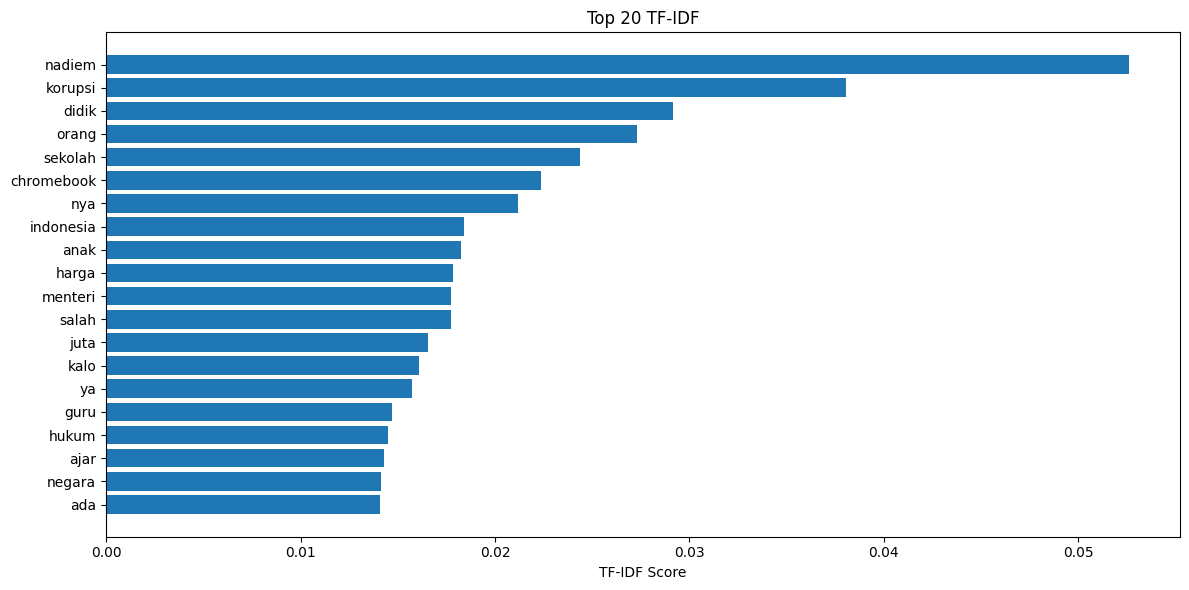

In [41]:
# ==========================================
# VISUALISASI TF-IDF
# ==========================================

import matplotlib.pyplot as plt

top20 = top_tfidf.head(20)

plt.figure(figsize=(12,6))

plt.barh(
    top20["Term"],
    top20["TF-IDF Score"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 TF-IDF")

plt.xlabel("TF-IDF Score")

plt.tight_layout()

plt.show()

In [42]:
top_tfidf.to_csv(
    "06_Top_TFIDF.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Top TF-IDF berhasil disimpan")

Top TF-IDF berhasil disimpan


### Count Word Frequency and workcloud

In [43]:
# ==========================================
# WORD FREQUENCY
# ==========================================

from collections import Counter
import pandas as pd

# ==========================================
# GABUNGKAN SEMUA TOKEN
# ==========================================

all_words = []

for tokens in df_relevan["stemmed_review_text"]:
    all_words.extend(tokens)

# ==========================================
# HITUNG FREKUENSI KATA
# ==========================================

word_freq = Counter(all_words)

# Ambil 20 kata teratas
top20 = pd.DataFrame(
    word_freq.most_common(20),
    columns=["Kata", "Frekuensi"]
)

print("="*50)
print("TOP 20 WORD FREQUENCY")
print("="*50)

display(top20)

# ==========================================
# SIMPAN
# ==========================================

top20.to_csv(
    "06_word_frequency.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nFile berhasil disimpan : 06_word_frequency.csv")

TOP 20 WORD FREQUENCY


,Kata,Frekuensi
0,nadiem,3042
1,korupsi,1730
2,orang,1491
3,didik,1325
4,sekolah,1186
5,nya,1018
6,chromebook,976
7,anak,911
8,harga,828
9,indonesia,800



File berhasil disimpan : 06_word_frequency.csv


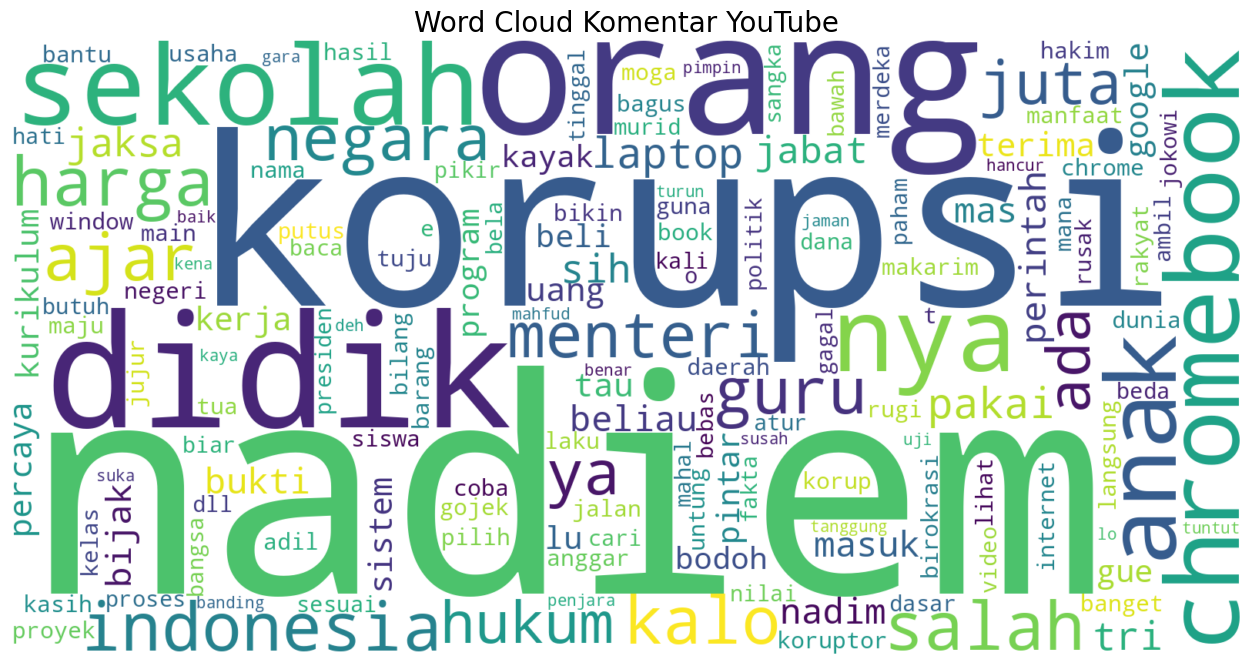

WordCloud berhasil disimpan : 07_wordcloud.png


In [44]:
# ==========================================
# WORD CLOUD
# ==========================================

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# ==========================================
# GABUNGKAN HASIL STEMMING
# ==========================================

text = " ".join(

    [
        " ".join(tokens)
        for tokens in df_relevan["stemmed_review_text"]
    ]

)

# ==========================================
# MEMBUAT WORD CLOUD
# ==========================================

wordcloud = WordCloud(

    width=1600,
    height=800,

    background_color="white",

    max_words=150,

    collocations=False

).generate(text)

# ==========================================
# TAMPILKAN
# ==========================================

plt.figure(figsize=(18,8))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")

plt.title("Word Cloud Komentar YouTube", fontsize=20)

plt.show()

# ==========================================
# SIMPAN GAMBAR
# ==========================================

wordcloud.to_file("07_wordcloud.png")

print("WordCloud berhasil disimpan : 07_wordcloud.png")

### NER

In [45]:
!pip install transformers sentencepiece torch accelerate -q

In [46]:
from transformers import pipeline
import pandas as pd
from tqdm.auto import tqdm

tqdm.pandas()

print("Loading NER Model...")

ner = pipeline(
    "ner",
    model="Davlan/xlm-roberta-base-ner-hrl",
    aggregation_strategy="simple"
)

def extract_entities(text):
    """
    Extracts named entities from the given text using the pre-loaded NER model.
    Handles non-string inputs by converting them to string.
    """
    if not isinstance(text, str):
        text = str(text)
    # If the text is empty after conversion, return an empty list to avoid errors
    if not text.strip():
        return []
    return ner(text)

print("Model berhasil dimuat!")
print("Fungsi extract_entities juga sudah didefinisikan.")

Loading NER Model...


config.json:   0%|          | 0.00/980 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/211 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Model berhasil dimuat!
Fungsi extract_entities juga sudah didefinisikan.


**Ekstrasi Entity**

In [47]:
from tqdm.auto import tqdm
import pandas as pd
import ast # To safely evaluate string representations of lists

# Load df_relevan from the last saved state
df_relevan = pd.read_csv("05_stemming.csv")

# Convert the 'stemmed_review_text' column from string representation of list to actual list
df_relevan['stemmed_review_text'] = df_relevan['stemmed_review_text'].apply(ast.literal_eval)

# Aktifkan progress bar
tqdm.pandas()

print("="*50)
print("PROSES EKSTRAKSI ENTITY")
print("="*50)

df_relevan["entities"] = (
    df_relevan["stemmed_review_text"]
    .fillna('') # Ensure no NaN values, fill with empty string (or empty list if you prefer that default)
    .apply(lambda x: " ".join(x) if isinstance(x, list) else str(x)) # Join list of tokens into a single string for NER input
    .progress_apply(extract_entities) # Apply NER pipeline
    .apply(lambda x: [entity['word'] for entity in x]) # Extract only the recognized words
)

print("="*50)
print("EKSTRAKSI ENTITY SELESAI")
print("="*50)

PROSES EKSTRAKSI ENTITY


  0%|          | 0/5633 [00:00<?, ?it/s]

EKSTRAKSI ENTITY SELESAI


In [81]:
df_relevan[
    [
        "comment",
        "stemmed_review_text",
        "entities"
    ]
].head(300)


,comment,stemmed_review_text,entities
0,Betul skrng KORUPSI itu sebagai alat Tawar.. A...,"[korupsi, alat, tawar, alat, sandera, kuasa, k...",[]
1,Tak adakah orang yg mau membela nadiem ini di ...,"[ada, orang, bela, nadiem, nkri]",[]
2,Kesalahan terbesar dan paling fatal Nadiem ada...,"[salah, besar, fatal, nadiem, gabung, perintah...",[]
3,Yang gk jelas dimana korupsi nya bisa seberat ...,"[mana, korupsi, nya, berat, kabar, korupsi, mb...",[]
4,yang jelas banget korupsi mbg dan kopdes malah...,"[banget, korupsi, mbak, kopdes, biar]",[]
...,...,...,...
295,"Hakim sperti itu , minta duit sama Nadiem gak...","[hakim, duit, nadiem, kasih, alami, vonis, hakim]",[]
296,Siapa yang mengajukan dan memilih Nadiem jadi ...,"[aju, pilih, nadiem, menteri]",[]
297,fyi knapa nadiem jadi target karna byk PERIOK ...,"[fyi, knapa, nadiem, target, periok, nasi, kor...",[]
298,Semua setuju jika korupsi hilang dari NKRI. \n...,"[tuju, korupsi, hilang, nkri, rakyat, tolol, b...",[]


In [80]:
from collections import Counter

# Gabungkan semua entity
all_entities = []

for entities in df_relevan["entities"]:
    all_entities.extend(entities)

entity_freq = Counter(all_entities)

top_entity = (
    pd.DataFrame(
        entity_freq.items(),
        columns=["Entity", "Frekuensi"]
    )
    .sort_values("Frekuensi", ascending=False)
    .reset_index(drop=True)
)

display(top_entity.head(20))

,Entity,Frekuensi
0,indonesia,373
1,google,94
2,na,80
3,,71
4,jokowi,61
5,pra,49
6,kemendikbud,45
7,nadim,43
8,dim,35
9,ke,32


In [50]:
top_entity.to_csv(
    "08_Top_Entity.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Top Entity berhasil disimpan.")

Top Entity berhasil disimpan.


### LDA Modeling

**Import Modeling LDA**

In [51]:
# ==========================================
# IMPORT LIBRARY
# ==========================================

import ast
import pandas as pd

from gensim import corpora
from gensim.models import LdaModel

###Load Dataset Stemming

In [52]:
# ==========================================
# LOAD DATA
# ==========================================

df_lda = pd.read_csv("05_stemming.csv")

# ubah string list menjadi list Python
df_lda["stemmed_review_text"] = df_lda["stemmed_review_text"].apply(ast.literal_eval)

print(df_lda.head())

                                           video_url  \
0  https://www.youtube.com/watch?v=rZmA0H_9s2o&t=...   
1  https://www.youtube.com/watch?v=rZmA0H_9s2o&t=...   
2  https://www.youtube.com/watch?v=rZmA0H_9s2o&t=...   
3  https://www.youtube.com/watch?v=rZmA0H_9s2o&t=...   
4  https://www.youtube.com/watch?v=rZmA0H_9s2o&t=...   

                   comment_id            author        comment_time  likes  \
0  Ugw1LT5mXTYkg4POuTd4AaABAg   @cobamining5705  27 detik yang lalu      0   
1  Ugw7bSjggk8WwMYnBh14AaABAg  @AnthoniusSinaga   7 menit yang lalu      0   
2  UgzhgCt5DlLvZ5UCqut4AaABAg         @Catto217  14 menit yang lalu      0   
3  UgyojRaQcAAjLpzmmJ14AaABAg  @AbdulAziz-ql3yw  17 menit yang lalu      0   
4  Ugxo9mp8P3oHNgyuqDR4AaABAg         @shaxxile  24 menit yang lalu      0   

                                             comment relevansi     text  \
0  Betul skrng KORUPSI itu sebagai alat Tawar.. A...   Relevan  Relevan   
1  Tak adakah orang yg mau membela nadiem in

### Membuat Dictionary LDA

In [53]:
# ==========================================
# MEMBUAT DICTIONARY
# ==========================================

dictionary = corpora.Dictionary(df_lda["stemmed_review_text"])

print("Jumlah kata unik :", len(dictionary))

Jumlah kata unik : 10020


### Membuat Corpus

In [54]:
# ==========================================
# MEMBUAT CORPUS
# ==========================================

corpus = [

    dictionary.doc2bow(text)

    for text in df_lda["stemmed_review_text"]

]

print("Jumlah Dokumen :", len(corpus))

Jumlah Dokumen : 5633


### Menjalankan LDA

In [55]:
# ==========================================
# MEMBUAT MODEL LDA
# ==========================================

lda_model = LdaModel(

    corpus=corpus,

    id2word=dictionary,

    num_topics=3,

    random_state=42,

    passes=20,

    alpha="auto",

    per_word_topics=True

)

print("LDA selesai dibuat.")

LDA selesai dibuat.


In [56]:
# ==========================================
# HASIL TOPIK
# ==========================================

for idx, topic in lda_model.print_topics():

    print("="*80)

    print(f"TOPIK {idx+1}")

    print(topic)

    print()

TOPIK 1
0.042*"sekolah" + 0.028*"anak" + 0.025*"ajar" + 0.025*"guru" + 0.017*"didik" + 0.013*"nadiem" + 0.013*"orang" + 0.010*"nya" + 0.009*"chromebook" + 0.008*"pakai"

TOPIK 2
0.043*"nadiem" + 0.027*"korupsi" + 0.020*"orang" + 0.017*"didik" + 0.013*"indonesia" + 0.011*"menteri" + 0.010*"negara" + 0.009*"salah" + 0.009*"hukum" + 0.009*"nya"

TOPIK 3
0.028*"harga" + 0.024*"chromebook" + 0.022*"juta" + 0.019*"ada" + 0.014*"laptop" + 0.011*"nya" + 0.009*"korupsi" + 0.009*"kalo" + 0.009*"nadiem" + 0.008*"beli"



### Menyimpan

In [57]:
# ==========================================
# SIMPAN TOPIK
# ==========================================

topics = []

for idx, topic in lda_model.print_topics():

    topics.append([

        idx + 1,

        topic

    ])

topic_df = pd.DataFrame(

    topics,

    columns=[

        "Topic",

        "Keywords"

    ]

)

display(topic_df)

topic_df.to_csv(

    "09_LDA_Topics.csv",

    index=False,

    encoding="utf-8-sig"

)

print("Topik berhasil disimpan.")

,Topic,Keywords
0,1,"0.042*""sekolah"" + 0.028*""anak"" + 0.025*""ajar"" ..."
1,2,"0.043*""nadiem"" + 0.027*""korupsi"" + 0.020*""oran..."
2,3,"0.028*""harga"" + 0.024*""chromebook"" + 0.022*""ju..."


Topik berhasil disimpan.


In [58]:
# ==========================================
# TOPIK DOMINAN
# ==========================================

dominant_topic = []

topic_probability = []

for bow in corpus:

    topics = lda_model.get_document_topics(bow)

    top = sorted(

        topics,

        key=lambda x: x[1],

        reverse=True

    )[0]

    dominant_topic.append(top[0] + 1)

    topic_probability.append(round(top[1],4))

df_lda["Dominant_Topic"] = dominant_topic

df_lda["Probability"] = topic_probability

### Menampilkan Hasil

In [59]:
df_lda[
[
    "comment",
    "Dominant_Topic",
    "Probability"
]
].head(30)

,comment,Dominant_Topic,Probability
0,Betul skrng KORUPSI itu sebagai alat Tawar.. A...,2,0.9854
1,Tak adakah orang yg mau membela nadiem ini di ...,2,0.7355
2,Kesalahan terbesar dan paling fatal Nadiem ada...,2,0.9801
3,Yang gk jelas dimana korupsi nya bisa seberat ...,3,0.5529
4,yang jelas banget korupsi mbg dan kopdes malah...,3,0.9492
5,Harusnya Korupsi MBG dan Kopdes di lihat lebih...,3,0.7276
6,@Om Helmy / admin pasti seru saran undang Dr ...,2,0.9949
7,Pak Makfud coba simak Podcast nya Akbar faisa...,1,0.9782
8,"Fix, dari pembicaraan tersebut, hakim saat itu...",2,0.9899
9,Ada Persamaan kah antara kasus Pak Nadim denga...,3,0.9763


###Visualisasi LDA (pyLDAvis)

In [60]:
!pip install pyLDAvis -q


In [61]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

pyLDAvis.enable_notebook()

In [62]:
# ==========================================
# VISUALISASI LDA
# ==========================================

lda_vis = gensimvis.prepare(

    lda_model,

    corpus,

    dictionary,

    sort_topics=False

)

lda_vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0     -0.119234  0.109763       1        1  24.831031
1     -0.051775 -0.142999       2        1  47.655298
2      0.171009  0.033236       3        1  27.513672, topic_info=          Term         Freq        Total Category  logprob  loglift
273    sekolah  1094.000000  1094.000000  Default  30.0000  30.0000
1370     harga   790.000000   790.000000  Default  29.0000  29.0000
420       anak   894.000000   894.000000  Default  28.0000  28.0000
192       guru   642.000000   642.000000  Default  27.0000  27.0000
396       juta   635.000000   635.000000  Default  26.0000  26.0000
...        ...          ...          ...      ...      ...      ...
4     perintah   127.069262   348.159276   Topic3  -5.4165   0.2826
11      nadiem   246.047608  2726.032177   Topic3  -4.7557  -1.1146
95       jaksa   127.915693   389.224758   Topic3  -5.4098   0.1777
287     negara   122.062886   648.471434   Topic3  -5.4567  -0.3796
165        sih   102.452889   427.866915   Topic3  -5.6318  -0.1389

[219 rows x 6 columns], token_table=      Topic      Freq    Term
term                         
9         1  0.059535     ada
9         3  0.940295     ada
49        1  0.044875    adil
49        2  0.862598    adil
49        3  0.089750    adil
...     ...       ...     ...
129       1  0.203452      ya
129       2  0.546681      ya
129       3  0.250044      ya
1848      1  0.992022  zonasi
1848      2  0.010020  zonasi

[301 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3])

In [63]:
pyLDAvis.save_html(

    lda_vis,

    "10_LDA_Visualization.html"

)

print("Visualisasi berhasil disimpan.")

Visualisasi berhasil disimpan.


In [64]:
# ==========================================
# TOP WORD SETIAP TOPIK
# ==========================================

topic_keywords = []

for topic_id in range(lda_model.num_topics):

    words = lda_model.show_topic(

        topic_id,

        topn=10

    )

    topic_keywords.append({

        "Topic": topic_id + 1,

        "Keywords": ", ".join(

            [word for word, prob in words]

        )

    })

topic_keywords = pd.DataFrame(topic_keywords)

topic_keywords

,Topic,Keywords
0,1,"sekolah, anak, ajar, guru, didik, nadiem, oran..."
1,2,"nadiem, korupsi, orang, didik, indonesia, ment..."
2,3,"harga, chromebook, juta, ada, laptop, nya, kor..."


In [65]:
topic_keywords.to_csv(

    "10_Topic_Keywords.csv",

    index=False,

    encoding="utf-8-sig"

)

print("Topic Keywords berhasil disimpan.")

Topic Keywords berhasil disimpan.


### Interpretasi Topik

In [66]:
topic_interpretation = pd.DataFrame({

    "Topic":[1,2,3],

    "Interpretasi":[
        "Kasus dugaan korupsi pengadaan Chromebook",
        "Nadiem Makarim dan kebijakan Kemendikbud",
        "Dampak digitalisasi pendidikan di sekolah"
    ]

})

topic_interpretation

,Topic,Interpretasi
0,1,Kasus dugaan korupsi pengadaan Chromebook
1,2,Nadiem Makarim dan kebijakan Kemendikbud
2,3,Dampak digitalisasi pendidikan di sekolah


In [67]:
topic_interpretation.to_csv(

    "10_Interpretasi_Topik.csv",

    index=False,

    encoding="utf-8-sig"

)

### Visualisasi

In [68]:
# ==========================================
# IMPORT LIBRARY
# ==========================================

import pandas as pd
import ast

from itertools import combinations
from collections import Counter

In [69]:
# ==========================================
# LOAD DATA HASIL STEMMING
# ==========================================

df_gephi = pd.read_csv("05_stemming.csv")

df_gephi.head()

,video_url,comment_id,author,comment_time,likes,comment,relevansi,text,cleaned_review_text,normalized_review_text,tokenized_review,filtered_review_text,removed_stopwords,stemmed_review_text
0,https://www.youtube.com/watch?v=rZmA0H_9s2o&t=...,Ugw1LT5mXTYkg4POuTd4AaABAg,@cobamining5705,27 detik yang lalu,0,Betul skrng KORUPSI itu sebagai alat Tawar.. A...,Relevan,Relevan,betul skrng korupsi itu sebagai alat tawar ala...,betul sekarang korupsi itu sebagai alat tawar ...,"['betul', 'sekarang', 'korupsi', 'itu', 'sebag...","['korupsi', 'alat', 'tawar', 'alat', 'sandera'...","['betul', 'sekarang', 'itu', 'sebagai', 'karen...","['korupsi', 'alat', 'tawar', 'alat', 'sandera'..."
1,https://www.youtube.com/watch?v=rZmA0H_9s2o&t=...,Ugw7bSjggk8WwMYnBh14AaABAg,@AnthoniusSinaga,7 menit yang lalu,0,Tak adakah orang yg mau membela nadiem ini di ...,Relevan,Relevan,tak adakah orang yg mau membela nadiem ini di ...,tak adakah orang yang mau membela nadiem ini d...,"['tak', 'adakah', 'orang', 'yang', 'mau', 'mem...","['adakah', 'orang', 'membela', 'nadiem', 'nkri']","['tak', 'yang', 'mau', 'ini', 'di']","['ada', 'orang', 'bela', 'nadiem', 'nkri']"
2,https://www.youtube.com/watch?v=rZmA0H_9s2o&t=...,UgzhgCt5DlLvZ5UCqut4AaABAg,@Catto217,14 menit yang lalu,0,Kesalahan terbesar dan paling fatal Nadiem ada...,Relevan,Relevan,kesalahan terbesar dan paling fatal nadiem ada...,kesalahan terbesar dan paling fatal nadiem ada...,"['kesalahan', 'terbesar', 'dan', 'paling', 'fa...","['kesalahan', 'terbesar', 'fatal', 'nadiem', '...","['dan', 'paling', 'adalah', 'mau', 'dengan', '...","['salah', 'besar', 'fatal', 'nadiem', 'gabung'..."
3,https://www.youtube.com/watch?v=rZmA0H_9s2o&t=...,UgyojRaQcAAjLpzmmJ14AaABAg,@AbdulAziz-ql3yw,17 menit yang lalu,0,Yang gk jelas dimana korupsi nya bisa seberat ...,Relevan,Relevan,yang gk jelas dimana korupsi nya bisa seberat ...,yang enggak jelas dimana korupsi nya bisa sebe...,"['yang', 'enggak', 'jelas', 'dimana', 'korupsi...","['dimana', 'korupsi', 'nya', 'seberat', 'kabar...","['yang', 'enggak', 'jelas', 'bisa', 'itu', 'ap...","['mana', 'korupsi', 'nya', 'berat', 'kabar', '..."
4,https://www.youtube.com/watch?v=rZmA0H_9s2o&t=...,Ugxo9mp8P3oHNgyuqDR4AaABAg,@shaxxile,24 menit yang lalu,0,yang jelas banget korupsi mbg dan kopdes malah...,Relevan,Relevan,yang jelas banget korupsi mbg dan kopdes malah...,yang jelas banget korupsi mbak dan kopdes mala...,"['yang', 'jelas', 'banget', 'korupsi', 'mbak',...","['banget', 'korupsi', 'mbak', 'kopdes', 'dibia...","['yang', 'jelas', 'dan', 'malah']","['banget', 'korupsi', 'mbak', 'kopdes', 'biar']"


In [70]:
# ==========================================
# UBAH STRING MENJADI LIST
# ==========================================

df_gephi["stemmed_review_text"] = df_gephi[
    "stemmed_review_text"
].apply(ast.literal_eval)

df_gephi.head()

,video_url,comment_id,author,comment_time,likes,comment,relevansi,text,cleaned_review_text,normalized_review_text,tokenized_review,filtered_review_text,removed_stopwords,stemmed_review_text
0,https://www.youtube.com/watch?v=rZmA0H_9s2o&t=...,Ugw1LT5mXTYkg4POuTd4AaABAg,@cobamining5705,27 detik yang lalu,0,Betul skrng KORUPSI itu sebagai alat Tawar.. A...,Relevan,Relevan,betul skrng korupsi itu sebagai alat tawar ala...,betul sekarang korupsi itu sebagai alat tawar ...,"['betul', 'sekarang', 'korupsi', 'itu', 'sebag...","['korupsi', 'alat', 'tawar', 'alat', 'sandera'...","['betul', 'sekarang', 'itu', 'sebagai', 'karen...","[korupsi, alat, tawar, alat, sandera, kuasa, k..."
1,https://www.youtube.com/watch?v=rZmA0H_9s2o&t=...,Ugw7bSjggk8WwMYnBh14AaABAg,@AnthoniusSinaga,7 menit yang lalu,0,Tak adakah orang yg mau membela nadiem ini di ...,Relevan,Relevan,tak adakah orang yg mau membela nadiem ini di ...,tak adakah orang yang mau membela nadiem ini d...,"['tak', 'adakah', 'orang', 'yang', 'mau', 'mem...","['adakah', 'orang', 'membela', 'nadiem', 'nkri']","['tak', 'yang', 'mau', 'ini', 'di']","[ada, orang, bela, nadiem, nkri]"
2,https://www.youtube.com/watch?v=rZmA0H_9s2o&t=...,UgzhgCt5DlLvZ5UCqut4AaABAg,@Catto217,14 menit yang lalu,0,Kesalahan terbesar dan paling fatal Nadiem ada...,Relevan,Relevan,kesalahan terbesar dan paling fatal nadiem ada...,kesalahan terbesar dan paling fatal nadiem ada...,"['kesalahan', 'terbesar', 'dan', 'paling', 'fa...","['kesalahan', 'terbesar', 'fatal', 'nadiem', '...","['dan', 'paling', 'adalah', 'mau', 'dengan', '...","[salah, besar, fatal, nadiem, gabung, perintah..."
3,https://www.youtube.com/watch?v=rZmA0H_9s2o&t=...,UgyojRaQcAAjLpzmmJ14AaABAg,@AbdulAziz-ql3yw,17 menit yang lalu,0,Yang gk jelas dimana korupsi nya bisa seberat ...,Relevan,Relevan,yang gk jelas dimana korupsi nya bisa seberat ...,yang enggak jelas dimana korupsi nya bisa sebe...,"['yang', 'enggak', 'jelas', 'dimana', 'korupsi...","['dimana', 'korupsi', 'nya', 'seberat', 'kabar...","['yang', 'enggak', 'jelas', 'bisa', 'itu', 'ap...","[mana, korupsi, nya, berat, kabar, korupsi, mb..."
4,https://www.youtube.com/watch?v=rZmA0H_9s2o&t=...,Ugxo9mp8P3oHNgyuqDR4AaABAg,@shaxxile,24 menit yang lalu,0,yang jelas banget korupsi mbg dan kopdes malah...,Relevan,Relevan,yang jelas banget korupsi mbg dan kopdes malah...,yang jelas banget korupsi mbak dan kopdes mala...,"['yang', 'jelas', 'banget', 'korupsi', 'mbak',...","['banget', 'korupsi', 'mbak', 'kopdes', 'dibia...","['yang', 'jelas', 'dan', 'malah']","[banget, korupsi, mbak, kopdes, biar]"


In [71]:
# ==========================================
# MEMBUAT EDGE
# ==========================================

edges = []

for words in df_gephi["stemmed_review_text"]:

    words = list(set(words))

    for pair in combinations(words,2):

        edges.append(tuple(sorted(pair)))

print("Jumlah Edge :",len(edges))

Jumlah Edge : 1265960


In [72]:
# ==========================================
# HITUNG BOBOT EDGE
# ==========================================

edge_counter = Counter(edges)

print("Jumlah hubungan unik :",len(edge_counter))

Jumlah hubungan unik : 729141


In [73]:
# ==========================================
# DATAFRAME EDGE
# ==========================================

edge_df = pd.DataFrame(

    [

        [source,target,weight]

        for (source,target),weight

        in edge_counter.items()

    ],

    columns=[

        "Source",

        "Target",

        "Weight"

    ]

)

edge_df.head()

,Source,Target,Weight
0,alat,kuasa,5
1,kuasa,sandera,1
2,kuasa,sebar,1
3,kanker,kuasa,1
4,korupsi,kuasa,30


In [74]:
# ==========================================
# SIMPAN EDGE
# ==========================================

edge_df.to_csv(

    "edge.csv",

    index=False,

    encoding="utf-8-sig"

)

print("edge.csv berhasil dibuat")

edge.csv berhasil dibuat


### Node

In [75]:
# ==========================================
# MEMBUAT NODE
# ==========================================

# Ambil semua kata unik
nodes = set(edge_df["Source"]).union(set(edge_df["Target"]))

# Buat DataFrame
node_df = pd.DataFrame({
    "Id": list(nodes),
    "Label": list(nodes)
})

print("="*60)
print("Jumlah Node :", len(node_df))
print("="*60)

node_df.head(10)

Jumlah Node : 10020


,Id,Label
0,objektif,objektif
1,delusion,delusion
2,tukar,tukar
3,tolakin,tolakin
4,poadcast,poadcast
5,ente,ente
6,memperjuangankan,memperjuangankan
7,ipeka,ipeka
8,manuver,manuver
9,radikalism,radikalism


### Simpan Node

In [76]:
# ==========================================
# SIMPAN NODE
# ==========================================

node_df.to_csv(
    "node.csv",
    index=False,
    encoding="utf-8-sig"
)

print("node.csv berhasil disimpan")

node.csv berhasil disimpan


### Statistik Network

In [77]:
# ==========================================
# STATISTIK NETWORK
# ==========================================

print("="*60)
print("STATISTIK SOCIAL NETWORK")
print("="*60)

print("Jumlah Node :", len(node_df))
print("Jumlah Edge :", len(edge_df))

print()

print("Top 10 Hubungan Terkuat")

edge_df.sort_values(
    by="Weight",
    ascending=False
).head(10)

STATISTIK SOCIAL NETWORK
Jumlah Node : 10020
Jumlah Edge : 729141

Top 10 Hubungan Terkuat


,Source,Target,Weight
38,nadiem,orang,431
71,nadiem,salah,352
5285,korupsi,nadiem,339
218,korupsi,orang,303
1251,didik,nadiem,295
859,nadiem,nya,283
1928,didik,orang,277
1224,indonesia,nadiem,274
1214,didik,indonesia,266
3635,kalo,nadiem,236


### Visualisasi Netwwork Static

In [78]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

for _, row in edge_df.iterrows():

    G.add_edge(
        row["Source"],
        row["Target"],
        weight=row["Weight"]
    )

print("Jumlah Node :", G.number_of_nodes())
print("Jumlah Edge :", G.number_of_edges())

Jumlah Node : 10020
Jumlah Edge : 729141


### Menampilkan Visualisasi

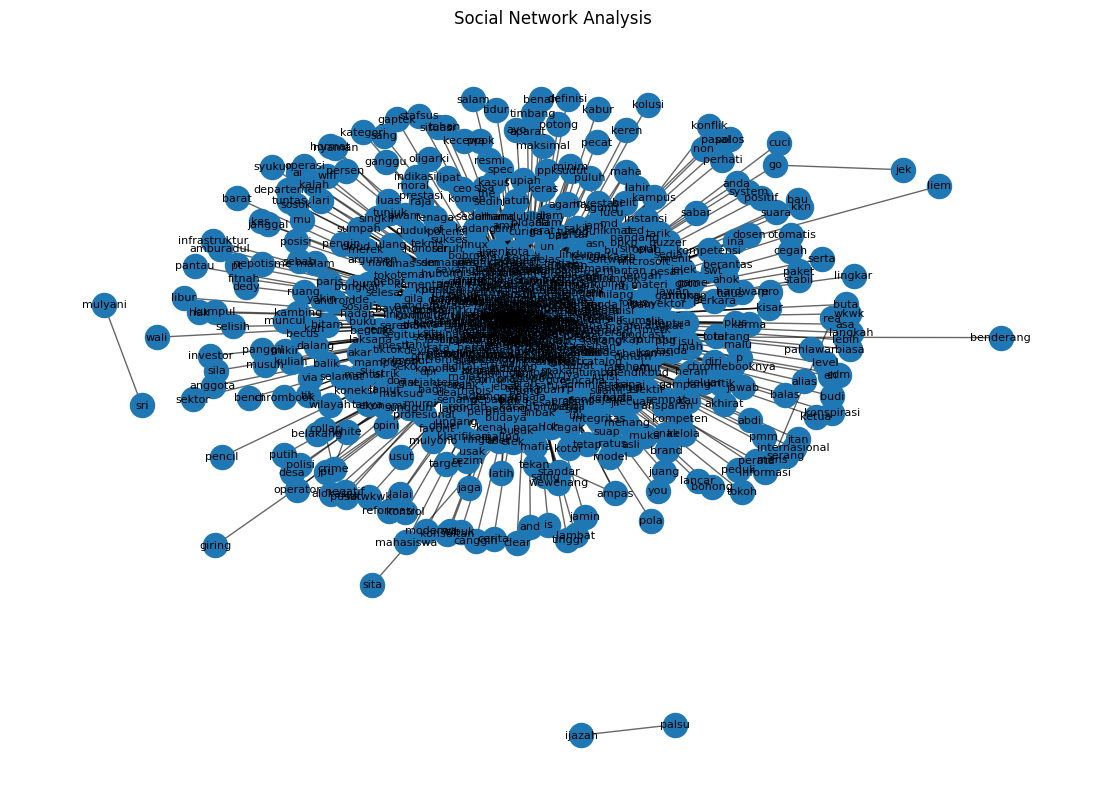

In [79]:
import networkx as nx
import matplotlib.pyplot as plt

# Ambil edge dengan bobot minimal 10
edge_filtered = edge_df[edge_df["Weight"] >= 10]

G = nx.Graph()

for _, row in edge_filtered.iterrows():

    G.add_edge(
        row["Source"],
        row["Target"],
        weight=row["Weight"]
    )

plt.figure(figsize=(14,10))

pos = nx.spring_layout(
    G,
    seed=42,
    k=0.5
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=300
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.6
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=8
)

plt.title("Social Network Analysis")
plt.axis("off")
plt.show()